STA 9891 - Final Project

<u>Group 3</u> - Lekshay Mertsi, Faraz Younus, Maryam Bibi


**Project Title:** Neural Network Analysis on the MNIST Dataset

**Course:** Machine Learning

**Objective:**
This project aims to provide students with practical experience in building and evaluating neural network models. Using the MNIST dataset, a classic in the field of machine learning, students will explore various neural network architectures, implement validation techniques, and critically analyze model performance.

**Dataset:**
The MNIST database, a large collection of handwritten digits, is a benchmark dataset in machine learning. It consists of 70,000 images (28x28 pixels) of handwritten digits (0-9). Students will use this dataset to train and test neural network models.

**Project Tasks:**

1. **Data Preparation:**
   - Load the MNIST dataset.
   - Normalize the image pixel values.
   - Split the data into training (70%), validation (10%), and testing (20%) sets.

2. **Model Building:**
   - Design various neural network architectures, starting from simple single-layer networks to more complex multi-layer architectures.
   - Experiment with different numbers of neurons, layers, and activation functions.

3. **Training with Validation and Patience:**
   - Use the validation dataset for early stopping with patience to prevent overfitting. Set patience equal to 10 epochs.

4. **Performance Evaluation:**
   - Train each neural network model on the training set.
   - Evaluate the final model performance on the test set.
   - Record key metrics such as train/test accuracy, loss over epochs for both training and validation sets.
   - Record the time used to train each model.

5. **Result Reporting:**
   - Present the results in a $3 \times M$ table, a row for train, test, and time, and a column for each model, where $M$ is the total number of models.

   - Create a $1 \times 2$ figure of train and test performance vs epochs, for all the models on the same figure, with each model distinguished by color and appropiate legends.

   - Discuss the impact of various architectures and training techniques on model performance.

6. **Models:**
   - `nn1` $784 \times 20 \times 10$
   - `nn2` $784 \times 40 \times 20 \times 10$
   - `nn3` $784 \times 80 \times 40 \times 20 \times 10$
   -  Use `Adam` with `l=0.001`
   -  The total number models to try is $M=3$.

**Deliverables:**
- A concise PDF of the notebook.
- Source code.




# Importing Libraries

In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
import time

# Data Preparation:

Loading the MNIST dataset and normalizing the image pixel values.

Splitting the data into training (70%), validation (10%), and testing (20%) sets


In [ ]:
# Data Preparation
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
full_dataset=torch.utils.data.ConcatDataset([train_dataset,test_dataset])

# Define the sizes for training, validation, and testing sets
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.1 * total_size)
test_size = int(0.2 * total_size)

# Use random_split to split the training dataset into training, validation, and testing sets
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Create DataLoaders for each set
train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1000, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 9912422/9912422 [00:00<00:00, 63133831.17it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 59206106.46it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 20523759.97it/s]

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw


100%|██████████| 4542/4542 [00:00<00:00, 4057620.61it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



# Model Building:

Designs of various neural network architectures, starting from simple single-layer network to more complex multi-layer architectures

In [ ]:
# Model 1: 784x20x10
class Net1(nn.Module):
    def __init__(self):
        super(Net1, self).__init__()
        self.fc1 = nn.Linear(784, 20)
        self.fc2 = nn.Linear(20, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Model 2: 784x40x20x10
class Net2(nn.Module):
    def __init__(self):
        super(Net2, self).__init__()
        self.fc1 = nn.Linear(784, 40)
        self.fc2 = nn.Linear(40, 20)
        self.fc3 = nn.Linear(20, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Model 3: 784x80x40x20x10
class Net3(nn.Module):
    def __init__(self):
        super(Net3, self).__init__()
        self.fc1 = nn.Linear(784, 80)
        self.fc2 = nn.Linear(80, 40)
        self.fc3 = nn.Linear(40, 20)
        self.fc4 = nn.Linear(20, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Model Instances and Optimizers

In [ ]:
# Create instances of the models and Adam optimizer
Model_nn1 = Net1()
optimizer_nn1 = torch.optim.Adam(Model_nn1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

Model_nn2 = Net2()
optimizer_nn2 = torch.optim.Adam(Model_nn2.parameters(), lr=0.001)

Model_nn3 = Net3()
optimizer_nn3 = torch.optim.Adam(Model_nn3.parameters(), lr=0.001)

# Early Stopping
Using the validation dataset for early stopping with patience to prevent overfitting. Patience is set to 10 epochs

In [ ]:
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')

    def __call__(self, current_loss):
        if current_loss < self.best_loss:
            self.best_loss = current_loss
            self.counter = 0
            return False  # No early stopping
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True  # Perform early stopping
            else:
                return False  # No early stopping

# Training with Validation and Patience:

Training each neural network model on the training set.
Evaluating the final model performance on the test set.
Recording key metrics such as train/test accuracy, loss over epochs for both training and validation sets, and validation accuracy in results dictionary.


In [ ]:
# Dictionaries to hold results for all three models
results = {
    "Model_nn1": {
        "train_accuracies": [],
        "test_accuracies": [],
        "train_losses": [],
        "times": []
    },
    "Model_nn2": {
        "train_accuracies": [],
        "test_accuracies": [],
        "train_losses": [],
        "times": []
    },
    "Model_nn3": {
        "train_accuracies": [],
        "test_accuracies": [],
        "train_losses": [],
        "times": []
    }
}

optimizers = {
    "Model_nn1": optimizer_nn1,
    "Model_nn2": optimizer_nn2,
    "Model_nn3": optimizer_nn3
}

models = {
    "Model_nn1": Model_nn1,
    "Model_nn2": Model_nn2,
    "Model_nn3": Model_nn3
}

def train_and_evaluate(model_name, model, train_loader, val_loader, test_loader, optimizer, num_epochs=120, patience=10):
    start_time = time.time()
    early_stopping = EarlyStopping(patience=patience)
    criterion = nn.CrossEntropyLoss()  # Move the criterion definition inside the function

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    test_accuracies = []
    times = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for i, data in enumerate(train_loader, 0):
            inputs, labels = data

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Calculate average training loss and accuracy
        average_train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train

        # Validation
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for data in val_loader:
                images, labels = data
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()

                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        # Calculate average validation loss and accuracy
        average_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct_val / total_val

        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for data in test_loader:
                images, labels = data
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        test_accuracy = 100 * correct_test / total_test

        # Record metrics
        train_losses.append(average_train_loss)
        val_losses.append(average_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        test_accuracies.append(test_accuracy)
        times.append(time.time() - start_time)

        # Check for early stopping
        if early_stopping(average_val_loss):
            print(f"Early stopping triggered for {model_name} at epoch {epoch}")
            print()
            break

        print(f"[{model_name} - Epoch {epoch+1}] "
              f"Train Accuracy: {train_accuracy:.2f}%, "
              f"Test Accuracy: {test_accuracy:.2f}%, "
              f"Train Loss: {average_train_loss:.3f}, "
              f"Validation Loss: {average_val_loss:.3f}, "
              f"Validation Accuracy: {val_accuracy:.2f}")

    results[model_name]["train_losses"] = train_losses
    results[model_name]["val_losses"] = val_losses
    results[model_name]["train_accuracies"] = train_accuracies
    results[model_name]["val_accuracies"] = val_accuracies
    results[model_name]["test_accuracies"] = test_accuracies
    results[model_name]["times"] = times

# Training Model_nn1, Model_nn2, and Model_nn3

In [ ]:
# Iterate over models and train each one
for model_name, model in models.items():
    optimizer = optimizers[model_name]
    train_loader =  train_loader
    val_loader =  val_loader
    test_loader =  test_loader

    train_and_evaluate(model_name, model, train_loader, val_loader, test_loader, optimizer)

[Model_nn1 - Epoch 1] Train Accuracy: 63.62%, Test Accuracy: 79.31%, Train Loss: 1.428, Validation Loss: 0.822, Validation Accuracy: 80.00
[Model_nn1 - Epoch 2] Train Accuracy: 84.32%, Test Accuracy: 86.82%, Train Loss: 0.637, Validation Loss: 0.504, Validation Accuracy: 87.37
[Model_nn1 - Epoch 3] Train Accuracy: 87.97%, Test Accuracy: 88.79%, Train Loss: 0.460, Validation Loss: 0.405, Validation Accuracy: 89.37
[Model_nn1 - Epoch 4] Train Accuracy: 89.31%, Test Accuracy: 89.76%, Train Loss: 0.394, Validation Loss: 0.361, Validation Accuracy: 90.16
[Model_nn1 - Epoch 5] Train Accuracy: 89.91%, Test Accuracy: 90.30%, Train Loss: 0.362, Validation Loss: 0.338, Validation Accuracy: 90.39
[Model_nn1 - Epoch 6] Train Accuracy: 90.32%, Test Accuracy: 90.76%, Train Loss: 0.342, Validation Loss: 0.327, Validation Accuracy: 90.71
[Model_nn1 - Epoch 7] Train Accuracy: 90.69%, Test Accuracy: 90.86%, Train Loss: 0.328, Validation Loss: 0.311, Validation Accuracy: 91.34
[Model_nn1 - Epoch 8] Train

# Result Reporting ($3$ x $3$ Table):

Presenting the results in a  3×𝑀  table, a row for train, test, and time, and a column for each of the 3 models

In [ ]:
import pandas as pd

# Convert results dictionary to a DataFrame
df_data = {"Train Accuracy": [], "Test Accuracy": [], "Time (s)": []}

models = []

for model_name, metrics in results.items():
    models.append(model_name)
    # Use second-to-last values to ensure we get the values before early stopping
    df_data["Train Accuracy"].append(metrics["train_accuracies"][-2])
    df_data["Test Accuracy"].append(metrics["test_accuracies"][-2])
    df_data["Time (s)"].append(metrics["times"][-2])

df = pd.DataFrame(df_data, index=models).transpose()

In [ ]:
import pandas as pd

# Styling the DataFrame
styled_df = df.style \
    .set_caption("Model Performance Summary") \
    .set_table_styles([
        {'selector': 'caption','props': [('font-size', '18px'), ('font-weight', 'bold')]},
        {'selector': 'th','props': [('border', '1px solid black'), ('text-align', 'center'), ('font-weight', 'bold')]},
        {'selector': 'td','props': [('border', '1px solid black'), ('text-align', 'center')]}])

# Display the styled DataFrame
styled_df


,Model_nn1,Model_nn2,Model_nn3
Train Accuracy,95.628571,98.089796,98.463265
Test Accuracy,94.528571,96.292857,96.557143
Time (s),2215.357643,1455.829943,1164.816102


# Result Reporting ($1$ x $2$ Figure):

Presenting the results in a  1×2  figure of train and test performance vs epochs, for all the models on the same figure, with each model distinguished by color and appropiate legends

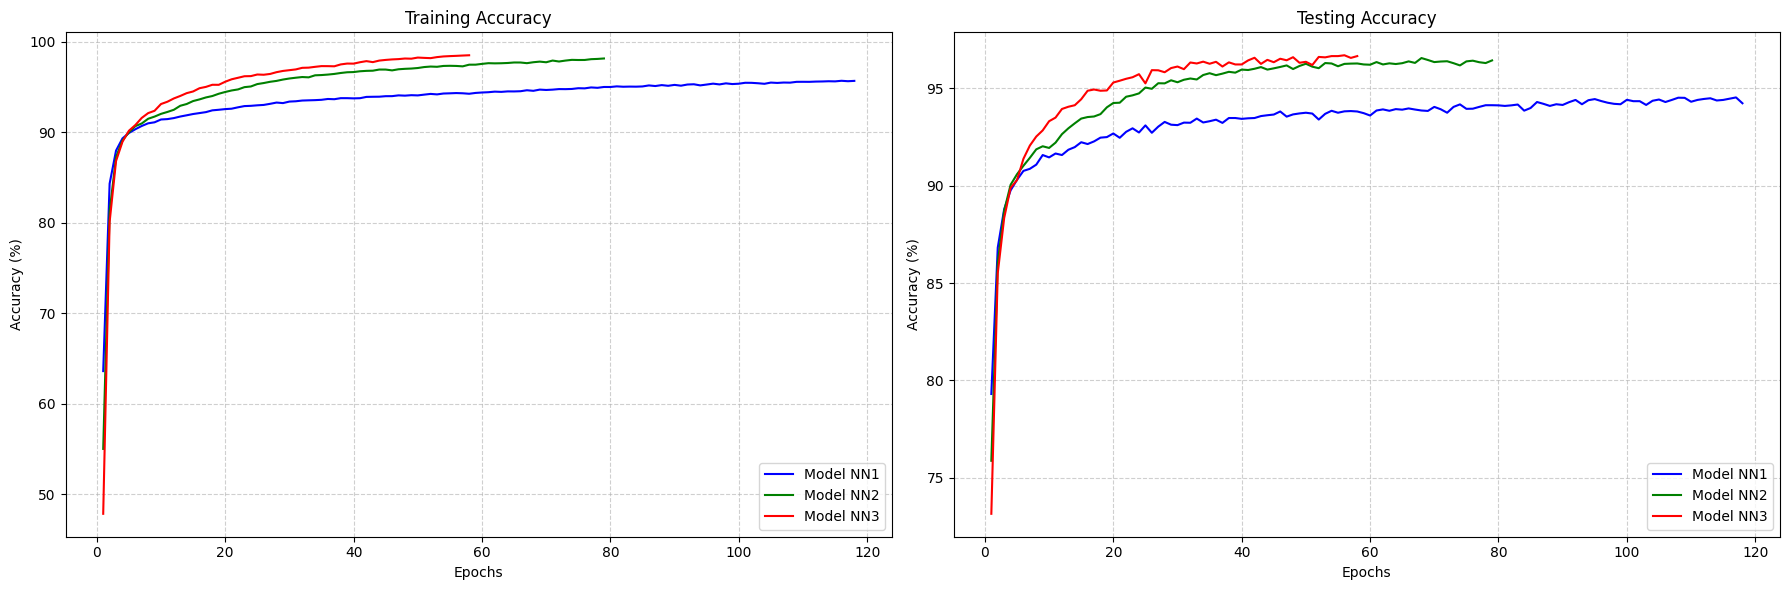

In [ ]:
import matplotlib.pyplot as plt

# Extract data for plotting
epochs_range1 = list(range(1, len(results["Model_nn1"]["train_accuracies"]) + 1))
epochs_range2 = list(range(1, len(results["Model_nn2"]["train_accuracies"]) + 1))
epochs_range3 = list(range(1, len(results["Model_nn3"]["train_accuracies"]) + 1))

accuracy_train_nn1 = results["Model_nn1"]["train_accuracies"]
accuracy_train_nn2 = results["Model_nn2"]["train_accuracies"]
accuracy_train_nn3 = results["Model_nn3"]["train_accuracies"]
accuracy_test_nn1 = results["Model_nn1"]["test_accuracies"]
accuracy_test_nn2 = results["Model_nn2"]["test_accuracies"]
accuracy_test_nn3 = results["Model_nn3"]["test_accuracies"]

# Create subplots
fig, axarr = plt.subplots(1, 2, figsize=(18, 6))

# Plot training accuracy for all three models
axarr[0].plot(epochs_range1, accuracy_train_nn1, label='Model NN1', color='blue')
axarr[0].plot(epochs_range2, accuracy_train_nn2, label='Model NN2', color='green')
axarr[0].plot(epochs_range3, accuracy_train_nn3, label='Model NN3', color='red')
axarr[0].set_title('Training Accuracy')
axarr[0].set_xlabel('Epochs')
axarr[0].set_ylabel('Accuracy (%)')
axarr[0].legend(loc='lower right')
axarr[0].grid(True, linestyle='--', alpha=0.6)

# Plot testing accuracy for all three models
axarr[1].plot(epochs_range1, accuracy_test_nn1, label='Model NN1', color='blue')
axarr[1].plot(epochs_range2, accuracy_test_nn2, label='Model NN2', color='green')
axarr[1].plot(epochs_range3, accuracy_test_nn3, label='Model NN3', color='red')
axarr[1].set_title('Testing Accuracy')
axarr[1].set_xlabel('Epochs')
axarr[1].set_ylabel('Accuracy (%)')
axarr[1].legend(loc='lower right')
axarr[1].grid(True, linestyle='--', alpha=0.6)

# Display ticks on both x and y axes
for ax in axarr:
    ax.tick_params(axis='both', which='both', direction='out', bottom=True, top=False, left=True, right=False)

plt.tight_layout()
plt.show()


# Discussion on the impact of various architectures and training techniques

1. **Model 1** (Net1: $784$ x $20$ x $10$):
This model consists of two fully connected layers with 20 and 10 neurons, respectively. The train accuracy is 95.63\% and the test accuracy is 94.53\%. The time to train this model was approximately 37 minutes.

2. **Model 2** (Net2: $784$ x $40$ x $20$ x $10$):
This model is a deeper version of Model 1, with three fully connected layers having 40, 20, and 10 neurons. The train accuracy is 98.09\% and the test accuracy is 96.29\%. This model was trained in approximately 24 minutes.

3. **Model 3** (Net3: $784$ x $80$ x $40$ x $20$ x $10$):
This model is even deeper, with four fully connected layers having 80, 40, 20, and 10 neurons. The train accuracy is 98.46\% and the test accuracy is 96.56\%. The time to train this model was approximately 19 minutes.

Deeper architectures (Models 2 and 3) have better performance, as seen in the higher test accuracies. Deeper models often have more capacity to learn complex patterns from the training data, leading to higher training accuracy. Architectures with more layers achieve higher training and test accuracy rates compared to the simpler model, indicating that the additional layers and neurons contribute to capturing more intricate patterns in the data. The use of early stopping with patience helped prevent overfitting for all models. We also see that the training time decreases with each added layer.

In conclusion, deeper architectures may lead to better performance, but it's crucial to monitor and manage overfitting, and training efficiency is also an important consideration. It's best to have a balance between model complexity and generalization to achieve optimal performance on both training and test datasets.

